In [ ]:
import warnings

warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch
from torch.utils.tensorboard import SummaryWriter



plt.style.use('seaborn')

In [ ]:
genome_scores = pd.read_csv('genome_scores.csv')
genome_tags = pd.read_csv('genome_tags.csv')
link = pd.read_csv('link.csv')
movie = pd.read_csv('movie.csv')
rating = pd.read_csv('rating.csv')
tag = pd.read_csv('tag.csv')

Text(0, 0.5, 'count')

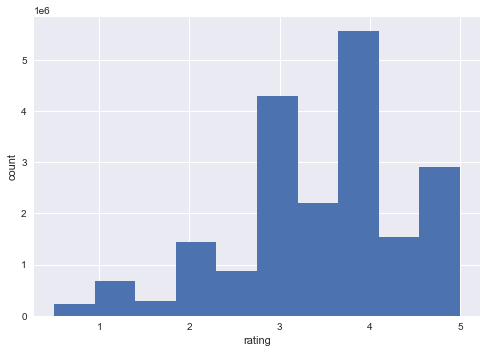

In [ ]:
plt.hist(rating["rating"])
plt.xlabel("rating")
plt.ylabel("count")


In [ ]:
rating['rank'] = rating.groupby("userId")['timestamp'].rank("max", ascending=False)

In [ ]:
train = rating[rating['rank'] != 1]
test = rating[rating['rank'] == 1]


In [ ]:
train[train['userId'] == 1]

,userId,movieId,rating,timestamp,rank
0,1,2,3.5,2005-04-02 23:53:47,20.0
1,1,29,3.5,2005-04-02 23:31:16,112.0
2,1,32,3.5,2005-04-02 23:33:39,96.0
3,1,47,3.5,2005-04-02 23:32:07,107.0
4,1,50,3.5,2005-04-02 23:29:40,122.0
...,...,...,...,...,...
170,1,8507,5.0,2004-09-10 03:13:47,150.0
171,1,8636,4.5,2005-04-02 23:44:53,71.0
172,1,8690,3.5,2005-04-02 23:33:15,100.0
173,1,8961,4.0,2005-04-02 23:47:09,62.0


In [ ]:
test[test['userId'] == 1]

,userId,movieId,rating,timestamp,rank
62,1,1750,3.5,2005-04-02 23:56:41,1.0


In [ ]:
train = train.drop(["timestamp", "rank"], axis=1).to_numpy()
test = test.drop(["timestamp", "rank"], axis=1).to_numpy()

In [ ]:
class MovieLensDataset(Dataset):
    def __init__(self, dataset):
        self.users, self.items, self.ratings = torch.tensor(dataset[:, 0]), torch.tensor(dataset[:, 1]), torch.tensor(
            dataset[:, 2])

    def __len__(self):
        return len(self.users)

    def __getitem__(self, index):
        return self.users[index].int(), self.items[index].int(), self.ratings[index].float()

In [ ]:
class NCF_MovieLens(nn.Module):
    def __init__(self, n_users, n_items, embedding_size=8):
        super().__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_size)
        self.item_embedding = nn.Embedding(n_items, embedding_size)
        self.fc1 = nn.Linear(in_features=2 * embedding_size, out_features=64)
        self.fc2 = nn.Linear(in_features=64, out_features=32)
        self.output = nn.Linear(in_features=32, out_features=1)

    def forward(self, user_input, item_input):
        user_input = self.user_embedding(user_input)
        item_input = self.item_embedding(item_input)
        embed = torch.cat([user_input, item_input], dim=-1)
        x = nn.ReLU()(self.fc1(embed))
        x = nn.ReLU()(self.fc2(x))
        x = self.output(x)
        return x

In [ ]:
train_loader = DataLoader(MovieLensDataset(train), batch_size=512)
test_loader = DataLoader(MovieLensDataset(test), batch_size=512)

In [33]:
def testing(test_loader, model):
    error = 0
    with torch.no_grad():
        for data in test_loader:
            users, items, ratings = data
            y_pred = model(users, items)
            error += nn.MSELoss()(y_pred, ratings.unsqueeze(1)).item()

    mse = error / len(test_loader)
    return mse

def training(logging_interval, train_loader, num_epochs = 1):
    loss_fn = torch.nn.MSELoss()
    net = NCF_MovieLens(rating['userId'].max() + 1, rating['movieId'].max() + 1)
    optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
    writer = SummaryWriter()

    losses = []
    for epoch in range(num_epochs):
        print(f'Starting epoch {epoch + 1}')

        current_loss = 0.0

        for i, data in enumerate(train_loader, 0):
            users, items, ratings = data
            outputs = net(users, items)
            optimizer.zero_grad()
            loss = loss_fn(outputs, ratings)
            loss.backward()
            optimizer.step()
            current_loss += loss.item()
            if i % logging_interval == logging_interval - 1:
                print('Loss after mini-batch %5d: %.3f' %
                      (i + 1, current_loss / logging_interval))
                losses.append(current_loss / logging_interval)
                writer.add_scalar("Loss/Train", current_loss / logging_interval)
                writer.add_scalar("Loss/Validation", testing(test_loader, net))
                current_loss = 0.0
            if i == 0:
                writer.add_graph(net, [users, items])

    print('Training process has finished.')
    return net

In [36]:
%load_ext tensorboard
%tensorboard --logdir=runs

model = training(1000, train_loader)


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Launching TensorBoard...

Starting epoch 1
Loss after mini-batch  1000: 1.667
Loss after mini-batch  2000: 1.166
Loss after mini-batch  3000: 1.151
Loss after mini-batch  4000: 1.130
Loss after mini-batch  5000: 1.160
Loss after mini-batch  6000: 1.152
Loss after mini-batch  7000: 1.128
Loss after mini-batch  8000: 1.138
Loss after mini-batch  9000: 1.132
Loss after mini-batch 10000: 1.102
Loss after mini-batch 11000: 1.133
Loss after mini-batch 12000: 1.102
Loss after mini-batch 13000: 1.136
Loss after mini-batch 14000: 1.117
Loss after mini-batch 15000: 1.146
Loss after mini-batch 16000: 1.107
Loss after mini-batch 17000: 1.097
Loss after mini-batch 18000: 1.153
Loss after mini-batch 19000: 1.132
Loss after mini-batch 20000: 1.114
Loss after mini-batch 21000: 1.173
Loss after mini-batch 22000: 1.142
Loss after mini-batch 23000: 1.087
Loss after mini-batch 24000: 1.131
Loss after mini-batch 25000: 1.120
Loss after mini-batch 26000: 1.133
Loss after mini-batch 27000: 1.147
Loss after mini-batch 28000: 1.080
Los

In [37]:
print(f"Rooot mean square error: {np.sqrt(testing(test_loader, model))}")

Rooot mean square error: 1.0567152057913833


Model Graph

![alt Model Graph](model_graph.png)

Learning process for different hyperparameters:
![alt Train plot](train.png)
![alt Validation plot](test.png)